In [149]:
import random
import copy
import torch
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np

from collections import defaultdict

from causal_gym import AntMazePCH
from causal_rl.algo.imitation.imitate import *
from causal_rl.algo.imitation.finetune import *
from causal_rl.algo.imitation.gail.core_net import *
from causal_rl.algo.imitation.gail.causal_gail import *
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "figure.dpi": 150,
})

In [150]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [151]:
num_steps = 1000
hidden_dims = {'O'}

In [152]:
# for eval: corrupted W, O hidden
eval_env = AntMazePCH(env_id='antmaze-large-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=False)

In [153]:
# load models
MODEL_PATH = '/home/et2842/causal/causalrl/models/cgail_k10_antlarge.pt'
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

action_bounds = (ckpt['action_bounds_low'], ckpt['action_bounds_high'])

causal_iqlearn_actor = ContinuousActor(
    num_inputs=ckpt['z_dim'],
    num_outputs=ckpt['action_dim'],
    hidden_size=ckpt['hidden_size_actor'],
    std=0.0,
    action_low=float(ckpt['action_bounds_low'].min()),
    action_high=float(ckpt['action_bounds_high'].max()),
    num_blocks=ckpt['num_blocks_actor'],
    dropout=ckpt['dropout_actor'],
    layernorm=ckpt['layernorm_actor'],
).to(device)

causal_iqlearn_actor.load_state_dict(ckpt['state_dict'])
causal_iqlearn_actor.eval()

causal_iqlearn_Z_trim = ckpt['Z_sets']
dims = ckpt['dims']
lookback = ckpt['lookback']

causal_iqlearn_encode, _, _ = build_windowed_z_encoder(causal_iqlearn_Z_trim, dims=dims, lookback=lookback)
causal_iqlearn_policy = make_gail_policy(causal_iqlearn_actor, causal_iqlearn_encode, device=device, deterministic=True)
causal_iqlearn_policies = make_shared_policy_dict(causal_iqlearn_policy)

In [154]:
num_eval_eps = 1

causal_iqlearn_returns = collect_imitator_trajectories(
    env=eval_env,
    policies=causal_iqlearn_policies,
    num_episodes=num_eval_eps,
    max_steps=num_steps,
    hidden_dims=hidden_dims,
    show_progress=True
)

len(causal_iqlearn_returns)

Starting episode 1/1...
  Episode 1 ended at step 1000 (terminated: False, truncated: True).
Finished collecting imitator trajectories.


1000

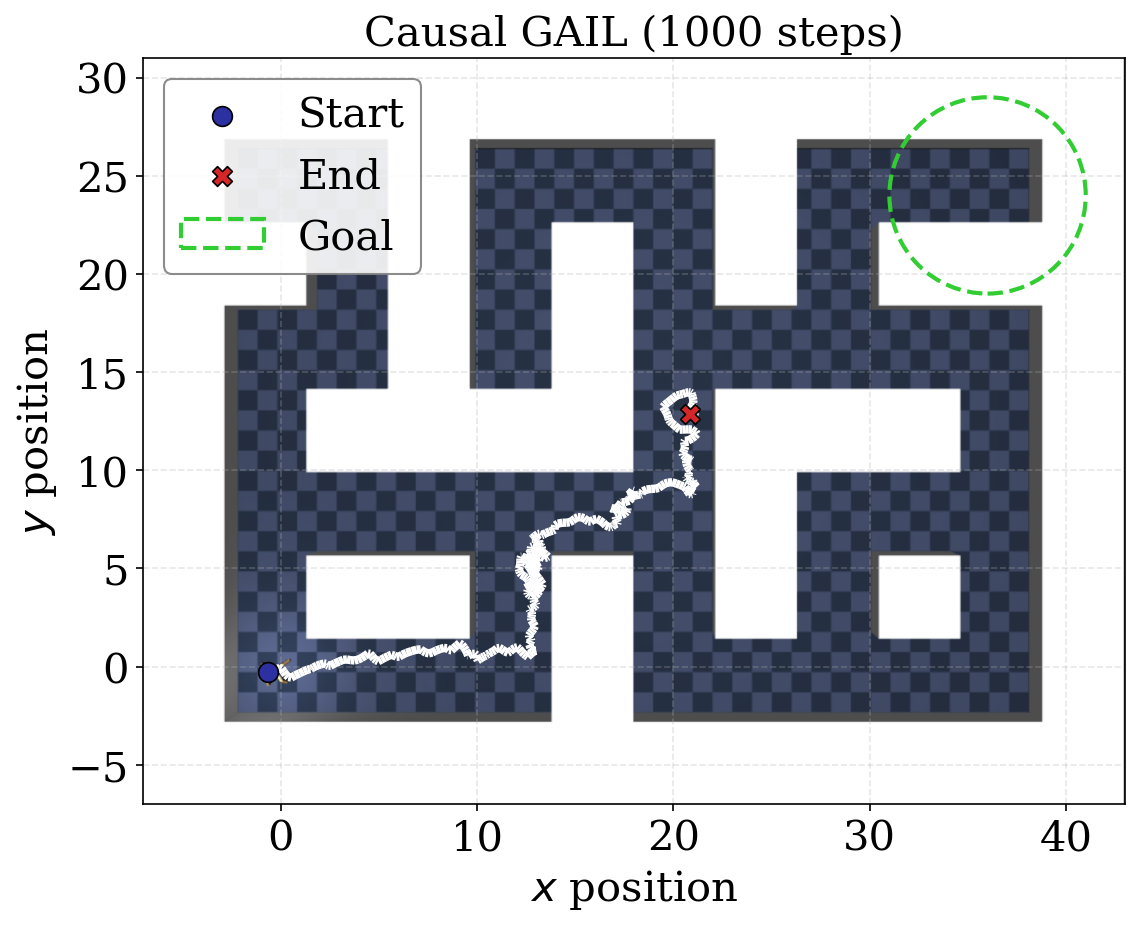

In [155]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.image import imread


def get_episode_xy_from_records(records, episode_id: int):
    ep = [r for r in records if r['episode'] == episode_id]
    ep = sorted(ep, key=lambda r: r['step'])
    xs, ys = [], []
    for r in ep:
        pos = r['obs']['P'][-1]
        xs.append(pos[0])
        ys.append(pos[1])
    return np.array(xs), np.array(ys)


def plot_ant_xy_trajectory(
    records,
    episode_id: int = 0,
    ax=None,
    title_prefix='AntMaze Large',
    maze_img_path=None,
    # --- Maze coordinate system ---
    maze_coord_min_x=-2.0,   # bottom-left corner of the maze
    maze_coord_max_x=38.0,   # top-right corner of the maze
    maze_coord_min_y=-2.0,
    maze_coord_max_y=26.0,
    border_units=5.0,      # white border in the PNG, in maze-coordinate units (per side)
):
    xs, ys = get_episode_xy_from_records(records, episode_id)
    T = len(xs)

    # Full extent of the image (maze coords + border on each side)
    img_min_x = maze_coord_min_x - border_units
    img_max_x = maze_coord_max_x + border_units
    img_min_y = maze_coord_min_y - border_units
    img_max_y = maze_coord_max_y + border_units


    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 12))
    else:
        fig = ax.figure

    # --- Draw maze background ---
    if maze_img_path is not None:
        maze_img = imread(maze_img_path)
        # extent = [left, right, bottom, top] in data coordinates
        ax.imshow(
            maze_img,
            extent=[img_min_x, img_max_x, img_min_y, img_max_y],
            origin='upper',
            aspect='equal',
            zorder=0,
        )

    # --- Trajectory ---
    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    t_norm = np.linspace(0, 1, T - 1)
    lc = LineCollection(segments, color='white', norm=plt.Normalize(0, 1))
    lc.set_array(t_norm)
    lc.set_linewidth(4.0)
    ax.add_collection(lc)

    ax.scatter(xs[0], ys[0], s=90, c="#2c30a0", marker='o',
               edgecolors='black', linewidths=0.8, zorder=5, label='Start')
    ax.scatter(xs[-1], ys[-1], s=90, c='#d62728', marker='X',
               edgecolors='black', linewidths=0.8, zorder=5, label='End')

    # Optional: draw goal circle
    goal_circle = plt.Circle((36, 24), 5, fill=False, edgecolor='limegreen',
                              linewidth=2, linestyle='--', zorder=4, label='Goal')
    ax.add_patch(goal_circle)

    # cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    # cbar.set_label('Time (normalized)')

    # --- Fix axes to full image extent so plot never shrinks ---
    ax.set_xlim(img_min_x, img_max_x)
    ax.set_ylim(img_min_y, img_max_y)
    ax.set_aspect('equal', 'box')

    ax.set_xlabel('$x$ position')
    ax.set_ylabel('$y$ position')
    ax.set_title(f'{title_prefix} ({T} steps)', fontsize=20)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', framealpha=0.9, edgecolor='gray')

    return fig, ax

rng = np.random.default_rng(42)
sample_eps = rng.choice(num_eval_eps, size=1, replace=False)

MAZE_PNG = '/home/et2842/causal/causalrl/examples/experiments/plots/visual_antlarge.png'

fig, ax = plt.subplots(figsize=(8, 8))
plot_ant_xy_trajectory(
    causal_iqlearn_returns,
    episode_id=int(sample_eps[0]),
    ax=ax,
    title_prefix='Causal GAIL',
    maze_img_path=MAZE_PNG,
)
plt.tight_layout()
plt.show()

In [157]:
fig.savefig('/home/et2842/causal/causalrl/examples/experiments/plots/antmaze-large/antlarge_cgail_traj.pdf', dpi=300, bbox_inches='tight')